<a href="https://colab.research.google.com/github/eduardo-hgombrade/FutebolPlacar/blob/main/footeboll.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚽ FutebolPlacar — Etapas 1 e 2
**Disciplina:** Desenvolvimento Rápido de Aplicações em Python  
**Instituição:** Unimetrocamp Wyden  
**Professor:** Mauro Rodrigues Alves Nogueira  
**Grupo:** Eduardo, Pedro, Vinícius, Rafael, Luana

---

## Etapa 1 — Leitura Inicial e EDA Básica (08/04 → 15/04)
Nesta etapa fazemos a **leitura dos arquivos CSV** diretamente da internet e uma **Análise Exploratória de Dados (EDA)** básica: entender o que existe, quantas linhas, quais colunas, tipos de dados, valores faltantes etc.

### 1.1 — Instalação e importação das bibliotecas

In [2]:
# Caso não tenha instalado, rode:
# pip install pandas matplotlib seaborn requests

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import io

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


### 1.2 — Leitura dos CSVs
Os arquivos estão disponíveis publicamente no DataHub. Vamos carregar as **últimas 5 temporadas** (2020/21 até 2024/25) e combinar tudo em um único DataFrame.

In [3]:
# URLs dos arquivos CSV por temporada
BASE_URL = 'https://datahub.io/core/english-premier-league/_r/-/'

temporadas = {
    '2020-21': 'season-2021.csv',
    '2021-22': 'season-2122.csv',
    '2022-23': 'season-2223.csv',
    '2023-24': 'season-2324.csv',
    '2024-25': 'season-2425.csv',
}

lista_dfs = []  # vai guardar cada DataFrame temporariamente

for nome, arquivo in temporadas.items():
    url = BASE_URL + arquivo
    resposta = requests.get(url)

    # Lê o CSV a partir do conteúdo baixado
    df_temp = pd.read_csv(io.StringIO(resposta.text))

    # Adiciona uma coluna indicando a temporada
    df_temp['Temporada'] = nome

    lista_dfs.append(df_temp)
    print(f'Temporada {nome}: {len(df_temp)} partidas carregadas')

# Combina todos os DataFrames em um só
df = pd.concat(lista_dfs, ignore_index=True)

print(f'\nTotal de partidas carregadas: {len(df)}')

Temporada 2020-21: 380 partidas carregadas
Temporada 2021-22: 380 partidas carregadas
Temporada 2022-23: 380 partidas carregadas
Temporada 2023-24: 380 partidas carregadas
Temporada 2024-25: 380 partidas carregadas

Total de partidas carregadas: 1900


### 1.3 — Primeiras visualizações dos dados
Antes de qualquer análise, precisamos **enxergar** como os dados são. As funções `.head()`, `.info()` e `.describe()` são as primeiras que todo analista de dados usa.

In [4]:
# Mostra as primeiras 5 linhas
print('=== Primeiras 5 linhas do DataFrame ===')
df.head()

=== Primeiras 5 linhas do DataFrame ===


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,AST,HF,AF,HC,AC,HY,AY,HR,AR,Temporada
0,12/09/20,Fulham,Arsenal,0,3,A,0,1,A,C Kavanagh,...,6,12,12,2,3,2,2,0,0,2020-21
1,12/09/20,Crystal Palace,Southampton,1,0,H,1,0,H,J Moss,...,5,14,11,7,3,2,1,0,0,2020-21
2,12/09/20,Liverpool,Leeds,4,3,H,3,2,H,M Oliver,...,3,9,6,9,0,1,0,0,0,2020-21
3,12/09/20,West Ham,Newcastle,0,2,A,0,0,D,S Attwell,...,2,13,7,8,7,2,2,0,0,2020-21
4,13/09/20,West Brom,Leicester,0,3,A,0,0,D,A Taylor,...,7,12,9,2,5,1,1,0,0,2020-21


In [5]:
# Informações gerais: tipos de dados, memória usada, valores não-nulos
print('=== Informações gerais do DataFrame ===')
df.info()

=== Informações gerais do DataFrame ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Data columns (total 23 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       1900 non-null   object
 1   HomeTeam   1900 non-null   object
 2   AwayTeam   1900 non-null   object
 3   FTHG       1900 non-null   int64 
 4   FTAG       1900 non-null   int64 
 5   FTR        1900 non-null   object
 6   HTHG       1900 non-null   int64 
 7   HTAG       1900 non-null   int64 
 8   HTR        1900 non-null   object
 9   Referee    1900 non-null   object
 10  HS         1900 non-null   int64 
 11  AS         1900 non-null   int64 
 12  HST        1900 non-null   int64 
 13  AST        1900 non-null   int64 
 14  HF         1900 non-null   int64 
 15  AF         1900 non-null   int64 
 16  HC         1900 non-null   int64 
 17  AC         1900 non-null   int64 
 18  HY         1900 non-null   int64 
 19  AY         1900 non-null   in

In [6]:
# Estatísticas descritivas das colunas numéricas
print('=== Estatísticas descritivas ===')
df.describe()

=== Estatísticas descritivas ===


,FTHG,FTAG,HTHG,HTAG,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
count,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000
mean,1.562632,1.353158,0.718947,0.598947,13.954211,11.751579,4.880526,4.163684,10.682105,10.852632,5.669474,4.701579,1.712632,1.903158,0.056842,0.062105
std,1.349731,1.236199,0.858596,0.802969,5.781843,5.223430,2.631670,2.398008,3.472148,3.594854,3.116353,2.835103,1.296712,1.347902,0.240525,0.249983
min,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,10.000000,8.000000,3.000000,2.000000,8.000000,8.000000,3.000000,3.000000,1.000000,1.000000,0.000000,0.000000
50%,1.000000,1.000000,1.000000,0.000000,13.000000,11.000000,5.000000,4.000000,11.000000,11.000000,5.000000,4.000000,2.000000,2.000000,0.000000,0.000000
75%,2.000000,2.000000,1.000000,1.000000,17.000000,15.000000,6.000000,6.000000,13.000000,13.000000,8.000000,6.000000,2.000000,3.000000,0.000000,0.000000
max,9.000000,8.000000,5.000000,5.000000,36.000000,37.000000,16.000000,15.000000,23.000000,25.000000,17.000000,19.000000,7.000000,8.000000,2.000000,2.000000


### 1.4 — Dicionário de colunas
Os nomes das colunas estão em inglês/abreviado. Aqui está o que cada uma significa:

In [7]:
dicionario = {
    'Date':     'Data da partida',
    'HomeTeam': 'Time mandante (casa)',
    'AwayTeam': 'Time visitante (fora)',
    'FTHG':     'Gols do mandante no tempo normal',
    'FTAG':     'Gols do visitante no tempo normal',
    'FTR':      'Resultado final (H=Casa, D=Empate, A=Fora)',
    'HTHG':     'Gols do mandante no 1º tempo',
    'HTAG':     'Gols do visitante no 1º tempo',
    'HTR':      'Resultado do 1º tempo',
    'Referee':  'Árbitro da partida',
    'HS':       'Chutes do mandante',
    'AS':       'Chutes do visitante',
    'HST':      'Chutes no gol do mandante',
    'AST':      'Chutes no gol do visitante',
    'HF':       'Faltas do mandante',
    'AF':       'Faltas do visitante',
    'HC':       'Escanteios do mandante',
    'AC':       'Escanteios do visitante',
    'HY':       'Cartões amarelos do mandante',
    'AY':       'Cartões amarelos do visitante',
    'HR':       'Cartões vermelhos do mandante',
    'AR':       'Cartões vermelhos do visitante',
    'Temporada':'Temporada (adicionada por nós)',
}

print('=== Dicionário de Dados ===')
for col, desc in dicionario.items():
    print(f'  {col:10s} → {desc}')

=== Dicionário de Dados ===
  Date       → Data da partida
  HomeTeam   → Time mandante (casa)
  AwayTeam   → Time visitante (fora)
  FTHG       → Gols do mandante no tempo normal
  FTAG       → Gols do visitante no tempo normal
  FTR        → Resultado final (H=Casa, D=Empate, A=Fora)
  HTHG       → Gols do mandante no 1º tempo
  HTAG       → Gols do visitante no 1º tempo
  HTR        → Resultado do 1º tempo
  Referee    → Árbitro da partida
  HS         → Chutes do mandante
  AS         → Chutes do visitante
  HST        → Chutes no gol do mandante
  AST        → Chutes no gol do visitante
  HF         → Faltas do mandante
  AF         → Faltas do visitante
  HC         → Escanteios do mandante
  AC         → Escanteios do visitante
  HY         → Cartões amarelos do mandante
  AY         → Cartões amarelos do visitante
  HR         → Cartões vermelhos do mandante
  AR         → Cartões vermelhos do visitante
  Temporada  → Temporada (adicionada por nós)


### 1.5 — EDA: Análise Exploratória Básica

In [8]:
# Quantas partidas por temporada?
print('=== Partidas por temporada ===')
print(df['Temporada'].value_counts().sort_index())

=== Partidas por temporada ===
Temporada
2020-21    380
2021-22    380
2022-23    380
2023-24    380
2024-25    380
Name: count, dtype: int64


=== Distribuição dos resultados (FTR) ===
FTR
H    821
A    646
D    433
Name: count, dtype: int64

Significado: H = vitória do mandante, D = empate, A = vitória do visitante


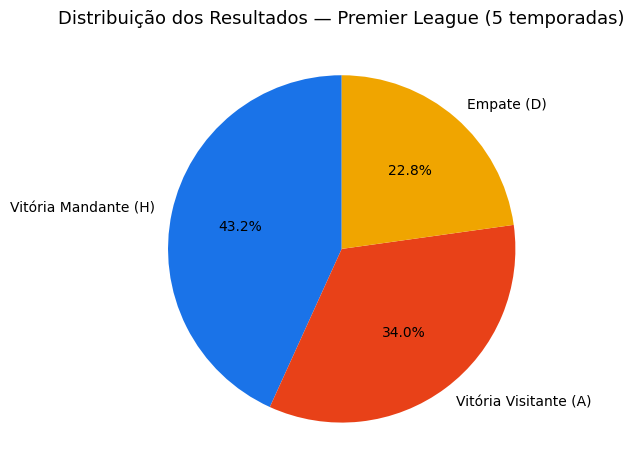

In [9]:
# Distribuição dos resultados finais
print('=== Distribuição dos resultados (FTR) ===')
contagem_resultados = df['FTR'].value_counts()
print(contagem_resultados)
print('\nSignificado: H = vitória do mandante, D = empate, A = vitória do visitante')

# Gráfico de pizza
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    contagem_resultados,
    labels=['Vitória Mandante (H)', 'Vitória Visitante (A)', 'Empate (D)'],
    autopct='%1.1f%%',
    colors=['#1a73e8', '#e84118', '#f0a500'],
    startangle=90
)
ax.set_title('Distribuição dos Resultados — Premier League (5 temporadas)', fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
# Times mais frequentes (mandantes)
print('=== Times com mais jogos como mandante ===')
print(df['HomeTeam'].value_counts().head(10))

=== Times com mais jogos como mandante ===
HomeTeam
Crystal Palace    95
Liverpool         95
West Ham          95
Man United        95
Tottenham         95
Brighton          95
Everton           95
Aston Villa       95
Chelsea           95
Newcastle         95
Name: count, dtype: int64


Média de gols por partida: 2.92


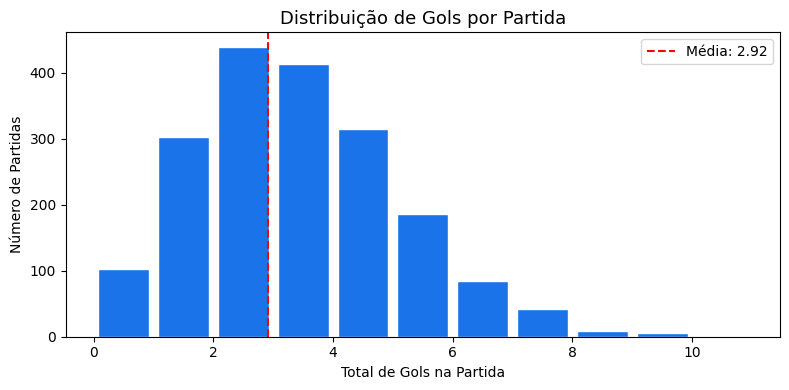

In [11]:
# Média de gols por partida
df['TotalGols'] = df['FTHG'] + df['FTAG']
media_gols = df['TotalGols'].mean()
print(f'Média de gols por partida: {media_gols:.2f}')

# Histograma de gols por partida
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['TotalGols'], bins=range(0, 12), color='#1a73e8', edgecolor='white', rwidth=0.85)
ax.set_title('Distribuição de Gols por Partida', fontsize=13)
ax.set_xlabel('Total de Gols na Partida')
ax.set_ylabel('Número de Partidas')
ax.axvline(media_gols, color='red', linestyle='--', label=f'Média: {media_gols:.2f}')
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# Verificar valores faltantes
print('=== Valores faltantes por coluna ===')
faltantes = df.isnull().sum()
print(faltantes[faltantes > 0] if faltantes.sum() > 0 else 'Nenhum valor faltante encontrado!')

=== Valores faltantes por coluna ===
Nenhum valor faltante encontrado!


---

## Etapa 2 — Tratamento de Dados (15/04 → 22/04)
Agora que exploramos os dados, passamos para a **limpeza e organização**. O objetivo é deixar o DataFrame pronto para ser usado no algoritmo de probabilidades.

### 2.1 — Conversão de tipos de dados

In [13]:
# A coluna Date vem como texto; precisamos converter para datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

print('Tipo da coluna Date após conversão:', df['Date'].dtype)
print('Exemplo de valor:', df['Date'].iloc[0])

Tipo da coluna Date após conversão: datetime64[ns]
Exemplo de valor: 2020-09-12 00:00:00


/tmp/ipykernel_10491/262808021.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')


### 2.2 — Remoção de colunas irrelevantes para o projeto
Colunas como `Referee` não serão usadas no cálculo de probabilidades nesta fase.

In [14]:
colunas_para_remover = ['Referee']

# Remove apenas as colunas que existem no DataFrame (evita erro)
colunas_existentes = [c for c in colunas_para_remover if c in df.columns]
df = df.drop(columns=colunas_existentes)

print(f'Colunas removidas: {colunas_existentes}')
print(f'Colunas restantes: {list(df.columns)}')

Colunas removidas: ['Referee']
Colunas restantes: ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'Temporada', 'TotalGols']


### 2.3 — Tratamento de valores faltantes

In [15]:
# Verifica novamente os nulos após a etapa anterior
faltantes = df.isnull().sum()
print('Valores faltantes:')
print(faltantes[faltantes > 0] if faltantes.sum() > 0 else 'Nenhum valor faltante!')

# Colunas numéricas: preenche nulos com 0 (caso haja partidas sem estatísticas detalhadas)
colunas_numericas = df.select_dtypes(include='number').columns
df[colunas_numericas] = df[colunas_numericas].fillna(0)

# Remove linhas em que time mandante ou visitante seja nulo (dado inválido)
antes = len(df)
df = df.dropna(subset=['HomeTeam', 'AwayTeam', 'FTR'])
depois = len(df)

print(f'\nLinhas removidas por dados inválidos: {antes - depois}')
print(f'Total de partidas após limpeza: {depois}')

Valores faltantes:
Nenhum valor faltante!

Linhas removidas por dados inválidos: 0
Total de partidas após limpeza: 1900


### 2.4 — Padronização dos nomes dos times
É comum que o mesmo time apareça com nomes levemente diferentes (ex: `"Man United"` vs `"Manchester United"`). Vamos checar e padronizar.

In [16]:
# Lista todos os times únicos
todos_times = sorted(set(df['HomeTeam'].unique()) | set(df['AwayTeam'].unique()))
print(f'Total de times únicos encontrados: {len(todos_times)}')
print('\nTimes:')
for time in todos_times:
    print(f'  - {time}')

Total de times únicos encontrados: 27

Times:
  - Arsenal
  - Aston Villa
  - Bournemouth
  - Brentford
  - Brighton
  - Burnley
  - Chelsea
  - Crystal Palace
  - Everton
  - Fulham
  - Ipswich
  - Leeds
  - Leicester
  - Liverpool
  - Luton
  - Man City
  - Man United
  - Newcastle
  - Norwich
  - Nott'm Forest
  - Sheffield United
  - Southampton
  - Tottenham
  - Watford
  - West Brom
  - West Ham
  - Wolves


In [17]:
# Mapa de padronização: substitui variações pelo nome oficial
# Adicione aqui outros casos que você encontrar
mapa_times = {
    'Man United':   'Manchester United',
    'Man City':     'Manchester City',
    "Nott'm Forest": 'Nottingham Forest',
    'Spurs':        'Tottenham',
    'Wolves':       'Wolverhampton',
}

df['HomeTeam'] = df['HomeTeam'].replace(mapa_times)
df['AwayTeam'] = df['AwayTeam'].replace(mapa_times)

print('Padronização aplicada!')
print(f'Times únicos após padronização: {len(sorted(set(df["HomeTeam"].unique()) | set(df["AwayTeam"].unique())))}')

Padronização aplicada!
Times únicos após padronização: 27


### 2.5 — Organização final: ordenar e resetar índice

In [18]:
# Ordena por data (da mais antiga para a mais recente)
df = df.sort_values('Date').reset_index(drop=True)

print('DataFrame ordenado por data.')
print(f'Período coberto: {df["Date"].min().date()} até {df["Date"].max().date()}')
df.head()

DataFrame ordenado por data.
Período coberto: 2020-09-12 até 2025-05-25


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HS,...,HF,AF,HC,AC,HY,AY,HR,AR,Temporada,TotalGols
0,2020-09-12,Fulham,Arsenal,0,3,A,0,1,A,5,...,12,12,2,3,2,2,0,0,2020-21,3
1,2020-09-12,Crystal Palace,Southampton,1,0,H,1,0,H,5,...,14,11,7,3,2,1,0,0,2020-21,1
2,2020-09-12,Liverpool,Leeds,4,3,H,3,2,H,22,...,9,6,9,0,1,0,0,0,2020-21,7
3,2020-09-12,West Ham,Newcastle,0,2,A,0,0,D,15,...,13,7,8,7,2,2,0,0,2020-21,2
4,2020-09-13,West Brom,Leicester,0,3,A,0,0,D,7,...,12,9,2,5,1,1,0,0,2020-21,3


### 2.6 — Salvando o DataFrame limpo
Exportamos o DataFrame tratado para um novo CSV. Esse arquivo será usado nas próximas etapas do projeto.

In [19]:
caminho_saida = 'dados_tratados.csv'
df.to_csv(caminho_saida, index=False)

print(f'Arquivo salvo em: {caminho_saida}')
print(f'Total de linhas: {len(df)}')
print(f'Total de colunas: {len(df.columns)}')

Arquivo salvo em: dados_tratados.csv
Total de linhas: 1900
Total de colunas: 23


---

## ✅ Resumo do que foi feito

| Etapa | O que fizemos |
|-------|---------------|
| **1 — Leitura** | Baixamos os CSVs das últimas 5 temporadas direto da URL |
| **1 — EDA** | Exploramos dimensões, tipos, estatísticas, distribuição de resultados e gols |
| **2 — Conversão** | Transformamos a coluna `Date` para o tipo `datetime` |
| **2 — Remoção** | Removemos colunas irrelevantes para o projeto (`Referee`) |
| **2 — Nulos** | Preenchemos zeros em colunas numéricas, removemos linhas inválidas |
| **2 — Padronização** | Unificamos variações de nomes de times |
| **2 — Exportação** | Salvamos `dados_tratados.csv` pronto para a próxima etapa |

**Próxima etapa (22/04):** Implementação do algoritmo de cálculo de probabilidades usando esse `dados_tratados.csv`.

---

## Etapa 3 — Algoritmo de Cálculo de Probabilidades (22/04)

Nesta etapa, vamos carregar o ficheiro `dados_tratados.csv` que gerámos anteriormente e criar a lógica do nosso backend. O objetivo é desenvolver uma função que receba o nome de duas equipas e devolva a probabilidade de vitória de cada uma, baseando-se no histórico de golos marcados e sofridos das últimas 5 temporadas.

In [20]:
import pandas as pd

# 1. Carregar os dados limpos
df_modelo = pd.read_csv('dados_tratados.csv')

def calcular_probabilidade(df, equipa_casa, equipa_visitante):
    """
    Calcula a probabilidade de vitória baseando-se no histórico de golos
    (FTHG e FTAG) das equipas jogando em casa e fora.
    """
    # Filtrar o histórico de jogos de cada equipa
    jogos_casa = df[df['HomeTeam'] == equipa_casa]
    jogos_visitante = df[df['AwayTeam'] == equipa_visitante]

    if jogos_casa.empty or jogos_visitante.empty:
        return "⚠️ Erro: Uma das equipas não foi encontrada na base de dados."

    # Força de Ataque e Defesa do Mandante
    media_marcados_casa = jogos_casa['FTHG'].mean()
    media_sofridos_casa = jogos_casa['FTAG'].mean()

    # Força de Ataque e Defesa do Visitante
    media_marcados_visitante = jogos_visitante['FTAG'].mean()
    media_sofridos_visitante = jogos_visitante['FTHG'].mean()

    # Cálculo da Expectativa de Golos
    # A equipa da casa marca com base no seu ataque e na defesa do visitante
    expectativa_golos_casa = (media_marcados_casa + media_sofridos_visitante) / 2
    expectativa_golos_visitante = (media_marcados_visitante + media_sofridos_casa) / 2

    # Cálculo das percentagens
    total_expectativa = expectativa_golos_casa + expectativa_golos_visitante

    if total_expectativa == 0:
        prob_casa = prob_visitante = prob_empate = 33.33
    else:
        # Atribuímos um peso fixo conservador para a probabilidade de empate (25%)
        peso_empate = 0.25
        margem_vitoria = 1 - peso_empate

        prob_casa = (expectativa_golos_casa / total_expectativa) * margem_vitoria * 100
        prob_visitante = (expectativa_golos_visitante / total_expectativa) * margem_vitoria * 100
        prob_empate = peso_empate * 100

    return prob_casa, prob_visitante, prob_empate

print("✅ Função de probabilidade carregada com sucesso!")

✅ Função de probabilidade carregada com sucesso!


In [21]:
# Definir as equipas para o teste (utilizando os nomes já padronizados)
equipa_1 = 'Arsenal'
equipa_2 = 'Manchester United'

prob_c, prob_v, prob_e = calcular_probabilidade(df_modelo, equipa_1, equipa_2)

print(f"📊 Previsão: {equipa_1} (Casa) x {equipa_2} (Fora)")
print("-" * 40)
print(f"Vitória do {equipa_1}: {prob_c:.2f}%")
print(f"Vitória do {equipa_2}: {prob_v:.2f}%")
print(f"Empate: {prob_e:.2f}%")
print("-" * 40)

📊 Previsão: Arsenal (Casa) x Manchester United (Fora)
----------------------------------------
Vitória do Arsenal: 44.87%
Vitória do Manchester United: 30.13%
Empate: 25.00%
----------------------------------------
